# **Fashion Product Generative AI**

## **Objective**
This notebook use a **generative AI model** to generate a natural language explanations based on input images and their visual similarity to other products.
We used **Llama API**.

In [27]:
!pip install pandas scikit-learn requests --quiet

In [62]:
!pip install torch torchvision --quiet

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from IPython.display import Markdown, display

In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from IPython.display import Markdown, display
import requests

In [11]:
# Load dataset
df = pd.read_csv("C:/FashionRecommendationsSystem/Dataset/fashion_products_cleaned.csv")

# Drop irrelevant columns
df_unlabeled = df.drop(columns=["id", "productDisplayName"], errors="ignore")

In [12]:
encoder = LabelEncoder()
for col in df_unlabeled.select_dtypes(include='object').columns:
    df_unlabeled[col] = encoder.fit_transform(df_unlabeled[col])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_unlabeled)

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

In [39]:
# Sample 5 items from a selected cluster
cluster_id = 1
recommended_items = df[df["Cluster"] == cluster_id].sample(n=5, random_state=42)[
    ["id","brandName", "ageGroup", "gender", "baseColour", "season"]
]

# Rename to match template format
recommended_items = recommended_items.rename(columns={
    "brandName": "brand",
    "baseColour": "color"
}).to_dict(orient="records")

# Show preview
pd.DataFrame(recommended_items)

,id,brand,ageGroup,gender,color,season
0,4150.0,Nike,Adults-Women,Women,Purple,Summer
1,14879.0,United Colors of Benetton,Adults-Women,Women,Black,Summer
2,9204.0,Puma,Adults-Men,Men,Black,Summer
3,15307.0,ADIDAS,Adults-Men,Men,Brown,Fall
4,22165.0,Timberland,Adults-Men,Men,Brown,Fall


In [63]:
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import numpy as np

# Load pretrained ResNet50 model
resnet_model = resnet50(pretrained=True)
resnet_model.eval()  # Set to inference mode

# Remove the final classification layer
feature_extractor = torch.nn.Sequential(*list(resnet_model.children())[:-1])

In [64]:
def extract_features(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],  # ImageNet means
            std=[0.229, 0.224, 0.225]    # ImageNet stds
        )
    ])

    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

    with torch.no_grad():
        features = feature_extractor(img_tensor)
    
    return features.squeeze().numpy().flatten()

In [34]:
TOGETHER_API_KEY = "15e5c4881e48578d1290a245dbba25115ed4f656230d05cebae3c02d900d247d" 

def call_llama(prompt, model = "mistralai/Mixtral-8x7B-Instruct-v0.1", temperature=0.7):
    headers = {
        "Authorization": f"Bearer {TOGETHER_API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": model,
        "prompt": prompt,
        "max_tokens": 300,
        "temperature": temperature,
        "top_p": 0.9,
        "repetition_penalty": 1.1,
    }

    response = requests.post(
        "https://api.together.xyz/v1/completions",
        headers=headers,
        json=payload
    )

    if response.status_code == 200:
        return response.json()["choices"][0]["text"]
    else:
        raise Exception(f"LLaMA API Error {response.status_code}: {response.text}")


In [35]:
prompt1 = template_informative(recommended_items)
prompt2 = template_friendly(recommended_items)

response1 = call_llama(prompt1)
response2 = call_llama(prompt2)

In [72]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the image features used for clustering (already extracted from ResNet)
features = np.load("../Supervised Learning/image_features.npy")  # Adjust path if needed

# Standardize features 
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)

# Retrain KMeans on scaled features
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

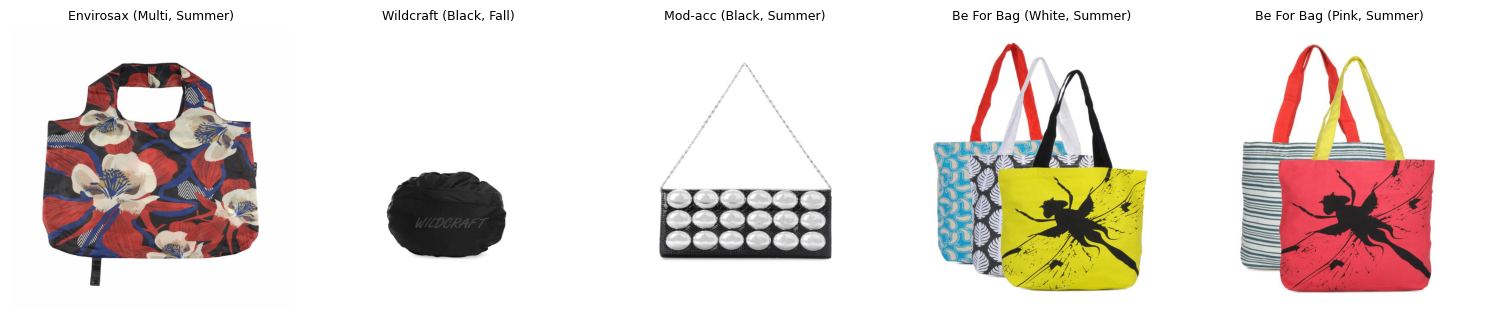

In [81]:
from sklearn.metrics.pairwise import cosine_similarity

# Filter all items from the predicted cluster
cluster_indices = df[df["Cluster"] == predicted_cluster].index
cluster_features = df_scaled[cluster_indices]

# Compute similarity with input image
sims = cosine_similarity(input_features_scaled, cluster_features)[0]

# Get top 5 most similar item indices in this cluster
top_n = 5
top_indices = cluster_indices[np.argsort(sims)[::-1][:top_n]]

# Get recommended item metadata
recommended_items = df.loc[top_indices][["id", "brandName", "ageGroup", "gender", "baseColour", "season"]]
recommended_items = recommended_items.rename(columns={
    "brandName": "brand",
    "baseColour": "color"
}).to_dict(orient="records")

# Visualize
display_recommendation_images(recommended_items, image_folder)

In [82]:
# Generate prompts from two styles
prompt1 = template_informative(recommended_items)
prompt2 = template_friendly(recommended_items)

# Call LLaMA 
response1 = call_llama(prompt1)
response2 = call_llama(prompt2)

# Display
display(Markdown("### Template 1: Informative Explanation"))
display(Markdown(response1))

display(Markdown("### Template 2: Conversational Stylist"))
display(Markdown(response2))

### Template 1: Informative Explanation



Answer: 

1. The Envirosax reusable shopping bag is recommended for adult women during summer due to its multi-color design that suits various summer outfits and occasions. The brand is known for sustainable products which align with the values of many people during this season.

2. The Wildcraft backpack is recommended for adults (unisex) in fall because of its neutral color (black) that matches most autumn clothing and weather conditions. It's versatile and suitable for both men and women.

3. The Mod-acc leather handbag is suggested for adult women in summer due to its black color which can be paired with various summer outfits. Leather bags are durable and stylish, making them a popular choice among women in many seasons but especially summer because they go well with casual or formal wear.

4. The Be For Bag tote is recommended for adult women in summer thanks to its white color which complements bright summer clothing and provides a clean, fresh look. Tote bags are practical and spacious, ideal for carrying beach essentials or daily necessities during the hot season.

5. The Be For Bag shoulder bag is also suggested for adult women in summer because of its pink color which adds a pop of vibrant energy to any summer outfit. Shoulder bags are convenient and fashionable, perfect for those who want to stay stylish while keeping their hands free during the

### Template 2: Conversational Stylist



Here’s how I would style this look: The Envirosax in the Multi color from the Summer collection is perfect to use as a beach bag or to carry your daily essentials when you’re on-the-go. The bright colors and playful pattern will add a pop of color to your outfit. Pair it with the Wildcraft Unisex bag in Black from the Fall collection to create a chic and edgy contrast. This backpack is great for carrying your laptop, books, or extra clothes when you need to transition from day to night. To complete the look, add in two Be For Bag bags in White and Pink from the Summer collection. These clutches are perfect for holding your phone, wallet, and other small essentials. The pink clutch adds a feminine touch, while the white clutch keeps the look clean and modern. Lastly, the Mod-acc bag in Black from the Summer collection can be worn as a crossbody or shoulder bag, making it versatile for any occasion. This sleek design will complement any outfit and tie the whole look together. Overall, this combination of bags is perfect for creating a stylish and functional everyday look that can take you from the beach to the office and everywhere in between!

### Comparison of Prompt Templates

**Template 1 - Informative Style**:
- Formal, structured, and detail-oriented
- Focuses on describing item attributes precisely
- Best for documentation or technical users

**Template 2 - Conversational (Stylist)**:
- Friendly, casual tone like a personal stylist
- Explains how items go together in a more human way
- More engaging and user-friendly for fashion shoppers


### Chosen Template
We selected **Template 2** as the preferred style for this system, because it delivers a more engaging and relatable experience for users seeking fashion advice.